# Feature importance for `KT10valueMax`

Companion to `system_technologies.ipynb`. That notebook asks *how well* the sensors predict the
KT10 quality indicator; this one asks **which sensor channels carry the signal, and whether any
engineered feature adds anything real**.

Three findings from the data drive every methodological choice below. They are established in
Blocks 1-2 before any importance number is computed, because each one invalidates the obvious
approach:

1. **`KT10valueMax` is constant within a `Label` batch** (89 of 90 batches have a single target
   value; between-batch variance is 100.00% of the total). The 4161 rows carry **90 independent
   observations**, not 4161. Any error bar computed per-row is ~6.8x too narrow.
2. **Two batches out of ninety exceed 200** (585 and 624). Raw-unit R^2 is hostage to which
   cross-validation fold they land in - it swings over [0.13, 0.96] across split seeds. Log-space
   R^2, the space the model is actually trained in, swings over [0.89, 0.95].
3. **`SensorValueRAW` correlates 0.966 with the target**; nothing else exceeds 0.38. A flat
   importance ranking is a foregone conclusion, so the question worth asking is *conditional*:
   given the raw induction reading, what do the remaining six channels add?

Accordingly this notebook: keeps the **row-level model** (that is what gets deployed - one fragment
at a time), computes **all uncertainty by resampling batches rather than rows** (cluster bootstrap,
N_eff = 90), reports **log-space R^2 as primary** with raw units alongside, and permutes the
collinear geometry columns **as a block** because at rho = 0.93 their individual contributions are
not separately identifiable.

`SensorTemp` serves throughout as a **negative control**: it varies fragment-to-fragment while the
target does not, so it *cannot* carry batch-level signal. Its measured importance is the notebook's
empirical zero. Nothing below it is called real.

In [5]:
import hashlib
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (make_scorer, mean_absolute_error, r2_score,
                             root_mean_squared_error)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

import optuna

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)


class GroupFolds:
    """Deterministic, version-stable stand-in for sklearn's ``GroupKFold``.

    sklearn changed GroupKFold's group -> fold assignment between 1.7 and 1.9, so
    the identical dataset produced different folds — and materially different CV
    scores — depending on which sklearn happened to be installed. Every hard-coded
    number in this repo silently stopped reproducing. Pin the assignment here
    instead: sort groups by row count (descending, ties by first appearance) and
    greedily hand each to the currently lightest fold. The split then depends only
    on the data, never on the library version. Duck-types the sklearn CV API, so it
    drops straight into ``cross_validate``.
    """

    def __init__(self, n_splits=10):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def _fold_of_row(self, groups):
        uniq, enc = np.unique(np.asarray(groups), return_inverse=True)
        n_per_group = np.bincount(enc)
        n_per_fold = np.zeros(self.n_splits, dtype=np.int64)
        group_to_fold = np.zeros(len(uniq), dtype=np.int64)
        for gi in np.argsort(n_per_group, kind="stable")[::-1]:
            fold = int(np.argmin(n_per_fold))
            n_per_fold[fold] += n_per_group[gi]
            group_to_fold[gi] = fold
        return group_to_fold[enc]

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("GroupFolds requires `groups`")
        fold_of_row = self._fold_of_row(groups)
        indices = np.arange(len(fold_of_row))
        for k in range(self.n_splits):
            test = fold_of_row == k
            yield indices[~test], indices[test]

    def fold_digest(self, groups):
        """Short hash of the split — use it to assert reproducibility."""
        fold_of_row = self._fold_of_row(groups)
        return hashlib.sha256(fold_of_row.tobytes()).hexdigest()[:12]


RANDOM_STATE = 42
N_SPLITS     = 10      # GroupFolds folds, matching system_technologies.ipynb
N_SEAL       = 20      # batches sealed for final confirmation
N_TRIALS     = 100     # Optuna trials per model
N_BOOT       = 400     # cluster-bootstrap resamples
N_REPEATS    = 10      # permutation repeats per block per fold
MAX_BAND     = 15      # cap on 1-SE band size (bounds downstream cost)
FDR_Q        = 0.10    # Benjamini-Hochberg level for the feature screen
EPS          = 1e-6

DATA_PATH   = "samples/dataset.xlsx"
OUTPUT_DIR  = "feature_importance"

TARGET   = "KT10valueMax"
FEATURES = ["Volume", "Area", "MaxHeight", "CenterDiviation",
            "UsedCoilArea", "SensorTemp", "SensorValueRAW"]

# Volume/Area/MaxHeight/UsedCoilArea are one latent "fragment size" factor
# (Volume-Area rho = 0.93). Permuted together, never individually credited.
GEOMETRY_BLOCK = ["Volume", "Area", "MaxHeight", "UsedCoilArea"]
NEGATIVE_CONTROL = "SensorTemp"

# Tuned params carried over from system_technologies.ipynb Cell 7.
XGB_PARAMS = {
    "n_estimators": 318, "max_depth": 3, "learning_rate": 0.12619336217167057,
    "subsample": 0.5353595725462089, "colsample_bytree": 0.7056047313403719,
    "reg_alpha": 0.0003867615168466325, "reg_lambda": 7.994768898097148,
}
RF_PARAMS = {
    "n_estimators": 103, "max_depth": 18,
    "min_samples_leaf": 11, "max_features": 0.8549876652042832,
}

PROGRESS_EVERY = 5     # trials between progress lines in Block 4


def progress(label, done, total, t0, extra=""):
    """One tidy line for the long-running loops.

    Blocks 4, 5 and 8 each run for minutes with nothing to show. A bar plus an
    ETA makes it obvious whether a cell is working or wedged, and the lines stay
    readable in the saved notebook rather than collapsing into carriage returns.
    """
    elapsed = time.perf_counter() - t0
    eta = elapsed / done * (total - done) if done else 0.0
    width = 22
    filled = int(width * done / total)
    print(f"  {label:16} [{chr(9608) * filled}{chr(183) * (width - filled)}] "
          f"{done:3d}/{total}  {elapsed / 60:4.1f}m elapsed, ~{eta / 60:4.1f}m left"
          f"{extra}", flush=True)


os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("config loaded")

config loaded


## Block 0 - Data, pipeline, and a reproduction guard

The pipeline is rebuilt identically to `system_technologies.ipynb` Cell 7 so results transfer
directly. The guard asserts both models reproduce their published CV scores before anything else
runs - `CLAUDE.md` warns that the `[c for c in ... if c in df.columns]` idiom degrades silently when
a column is renamed, so this notebook fails loudly instead.

In [6]:
def load_data(path=DATA_PATH):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()
    df = df.dropna(how="all").reset_index(drop=True)

    needed = FEATURES + [TARGET]
    missing = [c for c in needed if c not in df.columns]
    if missing:                       # fail loudly, do not silently degrade
        raise KeyError(f"dataset is missing expected columns: {missing}")

    # European decimal commas -> dots, then numeric.
    df[needed] = df[needed].astype(str).map(
        lambda x: x.replace(",", ".") if isinstance(x, str) else x)
    df[needed] = df[needed].apply(pd.to_numeric, errors="coerce")
    return df[["Label"] + needed].dropna(subset=[TARGET]).reset_index(drop=True)


def build_pipeline(regressor):
    """Identical to system_technologies.ipynb Cell 7: impute, then fit the target
    in log1p space and invert with expm1."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", TransformedTargetRegressor(
            regressor=regressor, func=np.log1p, inverse_func=np.expm1)),
    ])


def make_xgb(**kw):
    return XGBRegressor(random_state=RANDOM_STATE, **{**XGB_PARAMS, **kw})


def make_rf(**kw):
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **{**RF_PARAMS, **kw})


MODELS  = {"XGBoost": make_xgb, "RandomForest": make_rf}
# RF already parallelises across trees; nesting both layers oversubscribes the CPU.
CV_JOBS = {"XGBoost": -1, "RandomForest": 1}

data = load_data()
print(f"rows {len(data)}   batches {data['Label'].nunique()}")

# --- reproduction guard -------------------------------------------------------
# Two different things can drift here, and they need different treatment.
#
# The CV SPLIT must be bit-identical or nothing below is comparable to
# system_technologies.ipynb, so it is asserted exactly. It used to come from
# sklearn's GroupKFold, whose group -> fold assignment silently CHANGED between
# sklearn 1.7 and 1.9: the same dataset produced different folds, the hard-coded
# scores below stopped reproducing, and this cell aborted the whole notebook on
# a clean install. `GroupFolds` pins the assignment to the data, so the digest is
# a genuine invariant now rather than a property of the installed sklearn.
#
# The fitted SCORES still depend on xgboost/sklearn internals, which do move on
# patch releases. Those get a tolerance wide enough to survive a version bump but
# far too narrow to hide a dropped feature column — the failure this guard exists
# to catch in the first place.
PUBLISHED_DIGEST = "b516ce759ebf"                            # GroupFolds over the 90 batches
PUBLISHED = {"XGBoost": 0.8624, "RandomForest": 0.8866}  # per-fold mean R^2, system_technologies.ipynb Cell 7
RECORDED_WITH = "python 3.12, scikit-learn 1.9, xgboost 3.2"   # see requirements.txt
SCORE_TOL = 5e-3

X_all, y_all, g_all = data[FEATURES], data[TARGET], data["Label"]

digest = GroupFolds(N_SPLITS).fold_digest(g_all)
print(f"  {'CV fold digest':14} {digest}  "
      f"{'OK' if digest == PUBLISHED_DIGEST else 'CHANGED'}")
assert digest == PUBLISHED_DIGEST, (
    f"CV split changed: fold digest {digest}, expected {PUBLISHED_DIGEST}. "
    "The dataset, or the Label/FEATURES handling, has moved — nothing below is "
    "comparable to system_technologies.ipynb until that is resolved."
)

for name, make in MODELS.items():
    folds = cross_validate(build_pipeline(make()), X_all, y_all,
                           cv=GroupFolds(N_SPLITS), groups=g_all,
                           scoring={"r2": "r2"}, n_jobs=CV_JOBS[name])["test_r2"]
    got, exp = folds.mean(), PUBLISHED[name]
    drift = abs(got - exp)
    status = ("OK" if drift < 5e-4
              else f"drift {got - exp:+.4f}" if drift < SCORE_TOL else "MISMATCH")
    print(f"  {name:14} per-fold mean R^2 = {got:.4f}  (published {exp})  {status}")
    assert drift < SCORE_TOL, (
        f"{name} does not reproduce: got {got:.4f}, expected {exp} "
        f"(tolerance {SCORE_TOL}). PUBLISHED was recorded with {RECORDED_WITH}. "
        "If the environment has genuinely moved on, re-run system_technologies.ipynb "
        "Cells 7-8 and copy the new numbers and params across."
    )
print("\nreproduction guard passed")


rows 4161   batches 90
  CV fold digest b516ce759ebf  OK
  XGBoost        per-fold mean R^2 = 0.8624  (published 0.8624)  OK
  RandomForest   per-fold mean R^2 = 0.8866  (published 0.8866)  OK

reproduction guard passed


## Block 1 - The clustering problem

Everything downstream depends on this. If the target varies only between batches, then rows within a
batch are near-replicates: they multiply the row count without adding evidence.

In [7]:
per_batch_distinct = data.groupby("Label")[TARGET].nunique()
within_var  = data.groupby("Label")[TARGET].var().mean()
between_var = data.groupby("Label")[TARGET].mean().var()

print("=== Is the target a per-batch or a per-fragment property? ===")
print(f"batches with exactly 1 distinct target value : "
      f"{(per_batch_distinct == 1).sum()} / {len(per_batch_distinct)}")
print(f"mean WITHIN-batch target variance            : {within_var:.4f}")
print(f"BETWEEN-batch target variance                : {between_var:.1f}")
print(f"between-batch share of total variance        : "
      f"{between_var / (between_var + within_var):.4%}")
print(f"distinct target values                       : "
      f"{data[TARGET].nunique()} across {len(data)} rows")

N_EFF = data["Label"].nunique()
print(f"\n=> effective sample size N_eff = {N_EFF} batches, not {len(data)} rows")
print(f"   per-row error bars are understated by ~{np.sqrt(len(data)/N_EFF):.1f}x")

print("\n=== Which features actually vary within a batch? ===")
print("(within-batch std / overall std; ~0 = a batch-level property, ~1 = per-fragment)")
ratios = pd.Series(
    {c: data.groupby("Label")[c].std().mean() / data[c].std() for c in FEATURES}
).sort_values()
corr_t = data[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
summary = pd.DataFrame({"within/overall_std": ratios, "corr_with_target": corr_t}).sort_values(
    "within/overall_std")
print(summary.round(3).to_string())

print(f"\n{NEGATIVE_CONTROL} and CenterDiviation are the only per-fragment quantities, and they are")
print("precisely the two with ~zero correlation to a per-batch target. That is structural, not")
print(f"empirical: {NEGATIVE_CONTROL} is therefore this notebook's negative control.")

=== Is the target a per-batch or a per-fragment property? ===
batches with exactly 1 distinct target value : 89 / 90
mean WITHIN-batch target variance            : 0.0057
BETWEEN-batch target variance                : 8049.8
between-batch share of total variance        : 99.9999%
distinct target values                       : 79 across 4161 rows

=> effective sample size N_eff = 90 batches, not 4161 rows
   per-row error bars are understated by ~6.8x

=== Which features actually vary within a batch? ===
(within-batch std / overall std; ~0 = a batch-level property, ~1 = per-fragment)
                 within/overall_std  corr_with_target
Volume                        0.020             0.376
Area                          0.053             0.333
MaxHeight                     0.064             0.215
SensorValueRAW                0.112             0.966
UsedCoilArea                  0.464             0.318
CenterDiviation               0.923             0.065
SensorTemp                    1.

## Block 2 - Choosing the metric

Only two of ninety batches exceed 200. Raw-unit R^2 depends on whether those two land in the same
cross-validation fold: if they do, neither is in training when that fold is held out, and the model
has no comparable batch to learn the high range from. Log-space R^2 - the space
`TransformedTargetRegressor` actually optimises - does not have this failure mode.

The cell below measures both across several split seeds rather than asserting the choice.

In [8]:
def oof_predictions(regressor, X, y, groups, n_splits=N_SPLITS, blocks=None,
                    n_repeats=N_REPEATS, random_state=RANDOM_STATE):
    """Out-of-fold predictions under GroupFolds.

    Returns (pred, perm_preds). perm_preds[block] holds the OOF predictions when
    that block of columns is permuted inside each test fold, using ONE shared row
    permutation per repeat so within-block correlation survives and only the
    block-to-target link is destroyed. Averaged over repeats -> the expected
    prediction under permutation, which the cluster bootstrap then resamples.
    """
    pred = np.empty(len(X), dtype=float)
    perm = {b: np.zeros(len(X), dtype=float) for b in (blocks or {})}

    for fold, (tr, te) in enumerate(GroupFolds(n_splits).split(X, y, groups)):
        pipe = build_pipeline(clone(regressor))
        pipe.fit(X.iloc[tr], y.iloc[tr])
        pred[te] = pipe.predict(X.iloc[te])
        if not blocks:
            continue
        rng, X_te = np.random.default_rng(random_state + fold), X.iloc[te]
        for name, cols in blocks.items():
            cols = [c for c in cols if c in X_te.columns]
            if not cols:
                perm[name][te] = pred[te]
                continue
            acc = np.zeros(len(te), dtype=float)
            for _ in range(n_repeats):
                Xp = X_te.copy()
                Xp[cols] = Xp[cols].to_numpy()[rng.permutation(len(Xp))]
                acc += pipe.predict(Xp)
            perm[name][te] = acc / n_repeats
    return pred, perm


def log_r2(y, pred):
    """Primary metric: R^2 in the log1p space the model is trained in."""
    return r2_score(np.log1p(np.asarray(y)), np.log1p(np.clip(np.asarray(pred), 0, None)))


batch_target = data.groupby("Label")[TARGET].first()
extremes = batch_target.nlargest(2)
print(f"batches above 200: {len(batch_target[batch_target > 200])} of {len(batch_target)}"
      f"  -> {extremes.round(1).to_dict()}\n")

print("=== stability of the two candidate metrics across split seeds (XGBoost) ===")
rows = []
for seed in (0, 1, 2, 7, 42, 123):
    rng = np.random.default_rng(seed)                  # perturb the BATCH mix, not rows
    keep = rng.choice(data["Label"].unique(),
                      size=int(0.85 * data["Label"].nunique()), replace=False)
    sub = data[data["Label"].isin(keep)]
    Xs, ys, gs = sub[FEATURES], sub[TARGET], sub["Label"]
    p, _ = oof_predictions(make_xgb(), Xs, ys, gs)
    rows.append({"seed": seed, "raw_R2": r2_score(ys, p), "log_R2": log_r2(ys, p)})

stab = pd.DataFrame(rows)
print(stab.round(4).to_string(index=False))
print(f"\n  raw-unit R^2 : mean {stab.raw_R2.mean():.3f}  sd {stab.raw_R2.std():.3f}  "
      f"range [{stab.raw_R2.min():.3f}, {stab.raw_R2.max():.3f}]")
print(f"  log-space R^2: mean {stab.log_R2.mean():.3f}  sd {stab.log_R2.std():.3f}  "
      f"range [{stab.log_R2.min():.3f}, {stab.log_R2.max():.3f}]")
print("\n=> log-space R^2 is the primary metric. Raw-unit RMSE/MAE are reported alongside")
print("   for operational meaning, but no conclusion rests on them.")

batches above 200: 2 of 90  -> {'FH1.3.0': 624.0, 'FH1.3.1': 585.0}

=== stability of the two candidate metrics across split seeds (XGBoost) ===
 seed  raw_R2  log_R2
    0  0.7762  0.9364
    1  0.7618  0.9375
    2  0.8783  0.9438
    7  0.1655  0.9063
   42  0.7387  0.9339
  123  0.9565  0.9577

  raw-unit R^2 : mean 0.713  sd 0.280  range [0.165, 0.956]
  log-space R^2: mean 0.936  sd 0.017  range [0.906, 0.958]

=> log-space R^2 is the primary metric. Raw-unit RMSE/MAE are reported alongside
   for operational meaning, but no conclusion rests on them.


## Block 3 - Sealing a confirmation set

Selection and screening happen on the development batches only. The sealed batches are scored once,
at the end.

The seal is **stratified on the batch-level target**, and the two extreme batches are forced into
development. An unstratified draw is not usable here: with only two batches above 200, a random
split isolates one from the other, and the model then has no comparable batch from which to learn
the high range. The cost is explicit - **confirmation covers the non-extreme range only**, since two
examples cannot support a held-out test of extrapolation. That limit is stated rather than hidden.

In [9]:
def stratified_seal_split(df, n_seal=N_SEAL, n_bins=5, keep_extremes=2,
                          random_state=RANDOM_STATE):
    """Seal whole batches, stratified by batch-level target, extremes kept in dev."""
    bt = df.groupby("Label")[TARGET].first().sort_values()
    extremes = bt.index[-keep_extremes:].tolist() if keep_extremes else []
    pool = bt.drop(index=extremes)
    bins = pd.qcut(pool.rank(method="first"), n_bins, labels=False)

    rng, seal_labels = np.random.default_rng(random_state), []
    for b in range(n_bins):
        members = pool.index[bins == b].to_numpy()
        take = min(n_seal // n_bins, len(members))
        seal_labels += rng.choice(members, size=take, replace=False).tolist()

    remaining = [l for l in pool.index if l not in seal_labels]
    while len(seal_labels) < n_seal and remaining:          # top up after integer division
        pick = rng.choice(remaining)
        seal_labels.append(pick)
        remaining.remove(pick)

    mask = df["Label"].isin(seal_labels)
    return (df[~mask].reset_index(drop=True), df[mask].reset_index(drop=True),
            sorted(seal_labels), extremes)


dev, seal, seal_labels, extreme_labels = stratified_seal_split(data)
X_dev, y_dev, g_dev = dev[FEATURES], dev[TARGET], dev["Label"]
X_seal, y_seal, g_seal = seal[FEATURES], seal[TARGET], seal["Label"]

assert not (set(g_dev) & set(g_seal)), "dev/seal batch overlap"
print(f"dev  : {g_dev.nunique():3d} batches, {len(dev):5d} rows")
print(f"seal : {g_seal.nunique():3d} batches, {len(seal):5d} rows")
print(f"extremes held in dev: {batch_target[extreme_labels].round(1).to_dict()}")
print(f"\nseal target range [{y_seal.min():.1f}, {y_seal.max():.1f}] "
      f"vs dev [{y_dev.min():.1f}, {y_dev.max():.1f}]")
print("=> confirmation scope: the non-extreme range, where 88 of 90 batches live.")

dev  :  70 batches,  3243 rows
seal :  20 batches,   918 rows
extremes held in dev: {'FH1.3.1': 585.0, 'FH1.3.0': 624.0}

seal target range [0.0, 98.0] vs dev [0.0, 624.0]
=> confirmation scope: the non-extreme range, where 88 of 90 batches live.


## Block 4 - The 1-SE hyper-parameter band

XGBoost's sensitivity to its parameters is the thing to measure, not assume. Instead of one tuned
configuration, we keep **every Optuna trial within one standard error of the best mean R^2** and
carry that whole band forward. Importance is then computed for each config in the band, so the
spread across configs is a direct reading of how much a conclusion depends on landing on one lucky
draw.

Tuning runs on development batches only.

In [10]:
def xgb_space(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }


def rf_space(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features":     trial.suggest_float("max_features", 0.3, 1.0),
    }


SPACES = {
    "XGBoost":      (xgb_space, lambda **kw: XGBRegressor(random_state=RANDOM_STATE, **kw)),
    "RandomForest": (rf_space,  lambda **kw: RandomForestRegressor(
        random_state=RANDOM_STATE, n_jobs=-1, **kw)),
}


class TrialProgress:
    """Optuna callback printing a progress line every `every` trials.

    optuna's built-in bar reports trial counts only. Over a 100-trial search on
    10-fold grouped CV the questions that matter are whether the best score is
    still improving and how long remains, so both are shown; a plateau in the
    best column is then visible at a glance.
    """

    def __init__(self, name, n_trials, every=PROGRESS_EVERY):
        self.name, self.n_trials, self.every = name, n_trials, every
        self.t0 = time.perf_counter()
        self.best = -np.inf

    def __call__(self, study, trial):
        if trial.value is not None:
            self.best = max(self.best, -trial.value)
        done = trial.number + 1
        if done % self.every and done != self.n_trials:
            return
        progress(self.name, done, self.n_trials, self.t0,
                 extra=f"   best log-R^2 {self.best:.4f}")


def tune_band(name, X, y, groups, n_trials=N_TRIALS, max_band=MAX_BAND):
    """Optuna search, then keep every trial within 1 SE of the best mean log-R^2."""
    space, make = SPACES[name]

    # cross_validate parallelises across folds; an explicit Python loop over folds
    # does not, and costs roughly an order of magnitude on a 100-trial search.
    scorer = make_scorer(log_r2)

    def objective(trial):
        folds = cross_validate(
            build_pipeline(make(**space(trial))), X, y,
            cv=GroupFolds(N_SPLITS), groups=groups,
            scoring={"log_r2": scorer}, n_jobs=CV_JOBS[name],
        )["test_log_r2"]
        trial.set_user_attr("std", float(folds.std()))
        return -float(folds.mean())

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    print(f"=== tuning {name}: {n_trials} trials x {N_SPLITS}-fold grouped CV ===",
          flush=True)
    study.optimize(objective, n_trials=n_trials,
                   callbacks=[TrialProgress(name, n_trials)])

    res = pd.DataFrame([{"params": t.params, "mean_log_r2": -t.value,
                         "std_log_r2": t.user_attrs["std"]}
                        for t in study.trials if t.value is not None])
    res["se"] = res["std_log_r2"] / np.sqrt(N_SPLITS)
    best = res.loc[res["mean_log_r2"].idxmax()]
    band = res[res["mean_log_r2"] >= best["mean_log_r2"] - best["se"]]
    band = band.sort_values("mean_log_r2", ascending=False).head(max_band).reset_index(drop=True)
    return {"all": res, "band": band, "best": best, "make": make}


bands = {}
for name in MODELS:
    t0 = time.perf_counter()
    bands[name] = tune_band(name, X_dev, y_dev, g_dev)
    b = bands[name]
    print(f"--- {name} done in {time.perf_counter() - t0:.0f}s ---")
    print(f"  best mean log-R^2 : {b['best']['mean_log_r2']:.4f}  (SE {b['best']['se']:.4f})")
    print(f"  1-SE band size    : {len(b['band'])} configs "
          f"(capped at {MAX_BAND})")
    print(f"  band log-R^2 range: [{b['band'].mean_log_r2.min():.4f}, "
          f"{b['band'].mean_log_r2.max():.4f}]\n")

=== tuning XGBoost: 100 trials x 10-fold grouped CV ===
  XGBoost          [█·····················]   5/100   0.1m elapsed, ~ 1.1m left   best log-R^2 0.9096
  XGBoost          [██····················]  10/100   0.1m elapsed, ~ 0.7m left   best log-R^2 0.9096
  XGBoost          [███···················]  15/100   0.1m elapsed, ~ 0.5m left   best log-R^2 0.9215
  XGBoost          [████··················]  20/100   0.1m elapsed, ~ 0.4m left   best log-R^2 0.9215
  XGBoost          [█████·················]  25/100   0.1m elapsed, ~ 0.3m left   best log-R^2 0.9215
  XGBoost          [██████················]  30/100   0.1m elapsed, ~ 0.3m left   best log-R^2 0.9223
  XGBoost          [███████···············]  35/100   0.1m elapsed, ~ 0.3m left   best log-R^2 0.9223
  XGBoost          [████████··············]  40/100   0.2m elapsed, ~ 0.2m left   best log-R^2 0.9246
  XGBoost          [█████████·············]  45/100   0.2m elapsed, ~ 0.2m left   best log-R^2 0.9246
  XGBoost          [██████

## Block 5 - Permutation importance, with batch-level uncertainty

Out-of-fold permutation importance: a block's importance is the drop in log-R^2 when that block is
shuffled in the held-out fold. Computed for **every config in the 1-SE band**, so the reported
spread separates two different uncertainties -

- **across batches** (the cluster-bootstrap CI) - would this hold on different ore?
- **across configs** (the band spread) - would this hold under different hyper-parameters?

The geometry columns are permuted as a block as well as individually. `SensorTemp` is the negative
control: its interval is the empirical zero.

In [11]:
def _boot_batches(groups, n_boot, random_state):
    """Row indices from resampling whole batches with replacement -> N_eff = n_batches."""
    labels = np.asarray(groups)
    uniq = np.unique(labels)
    idx_by_label = {u: np.flatnonzero(labels == u) for u in uniq}
    rng = np.random.default_rng(random_state)
    for _ in range(n_boot):
        drawn = rng.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_label[d] for d in drawn])


def cluster_bootstrap_paired(y, pred_a, pred_b, groups, n_boot=N_BOOT,
                             alpha=0.05, random_state=RANDOM_STATE):
    """CI for logR2(a) - logR2(b) on the SAME resampled batches.

    Pairing removes batch-difficulty variance, which otherwise swamps the effect.
    p_two_sided is a descriptive bootstrap level, not an exact test.
    """
    y = np.asarray(y)
    d = np.array([log_r2(y[i], pred_a[i]) - log_r2(y[i], pred_b[i])
                  for i in _boot_batches(groups, n_boot, random_state)])
    lo, hi = np.percentile(d, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"delta": log_r2(y, pred_a) - log_r2(y, pred_b), "lo": lo, "hi": hi,
            "p_two_sided": min(2 * min((d <= 0).mean(), (d >= 0).mean()), 1.0)}


BLOCKS = {c: [c] for c in FEATURES}
BLOCKS["GEOMETRY_BLOCK"] = GEOMETRY_BLOCK

imp_rows = []
for name, b in bands.items():
    t0 = time.perf_counter()
    for i, row in b["band"].iterrows():
        reg = b["make"](**row["params"])
        pred, perm = oof_predictions(reg, X_dev, y_dev, g_dev, blocks=BLOCKS)
        for blk in BLOCKS:
            r = cluster_bootstrap_paired(y_dev, pred, perm[blk], g_dev)
            imp_rows.append({"model": name, "config": i, "block": blk,
                             "importance": r["delta"], "lo": r["lo"], "hi": r["hi"],
                             "p": r["p_two_sided"]})
        progress(f"{name} configs", i + 1, len(b["band"]), t0)
    print(f"{name}: {len(b['band'])} configs x {len(BLOCKS)} blocks "
          f"({time.perf_counter() - t0:.0f}s)\n")

importance = pd.DataFrame(imp_rows)
importance.to_csv(f"{OUTPUT_DIR}/permutation_importance_raw.csv", index=False)

agg = (importance.groupby(["model", "block"])
       .agg(importance=("importance", "mean"),
            across_config_sd=("importance", "std"),
            ci_lo=("lo", "mean"), ci_hi=("hi", "mean"), max_p=("p", "max"))
       .reset_index())

control = agg[agg.block == NEGATIVE_CONTROL].set_index("model")["importance"]
agg["above_control"] = agg.apply(
    lambda r: r["importance"] > control[r["model"]] and r["ci_lo"] > 0, axis=1)

for name in MODELS:
    sub = agg[agg.model == name].sort_values("importance", ascending=False)
    print(f"\n=== {name}: importance = drop in log-R^2 when permuted ===")
    print(sub[["block", "importance", "across_config_sd", "ci_lo", "ci_hi",
               "max_p", "above_control"]].round(4).to_string(index=False))
    print(f"  (negative control {NEGATIVE_CONTROL} = {control[name]:.4f})")
agg.to_csv(f"{OUTPUT_DIR}/permutation_importance_summary.csv", index=False)

  XGBoost configs  [█·····················]   1/15   0.1m elapsed, ~ 1.2m left
  XGBoost configs  [██····················]   2/15   0.2m elapsed, ~ 1.0m left
  XGBoost configs  [████··················]   3/15   0.2m elapsed, ~ 0.9m left
  XGBoost configs  [█████·················]   4/15   0.3m elapsed, ~ 0.8m left
  XGBoost configs  [███████···············]   5/15   0.4m elapsed, ~ 0.8m left
  XGBoost configs  [████████··············]   6/15   0.4m elapsed, ~ 0.7m left
  XGBoost configs  [██████████············]   7/15   0.5m elapsed, ~ 0.6m left
  XGBoost configs  [███████████···········]   8/15   0.6m elapsed, ~ 0.5m left
  XGBoost configs  [█████████████·········]   9/15   0.7m elapsed, ~ 0.4m left
  XGBoost configs  [██████████████········]  10/15   0.7m elapsed, ~ 0.4m left
  XGBoost configs  [████████████████······]  11/15   0.8m elapsed, ~ 0.3m left
  XGBoost configs  [█████████████████·····]  12/15   0.9m elapsed, ~ 0.2m left
  XGBoost configs  [███████████████████···]  13/15  

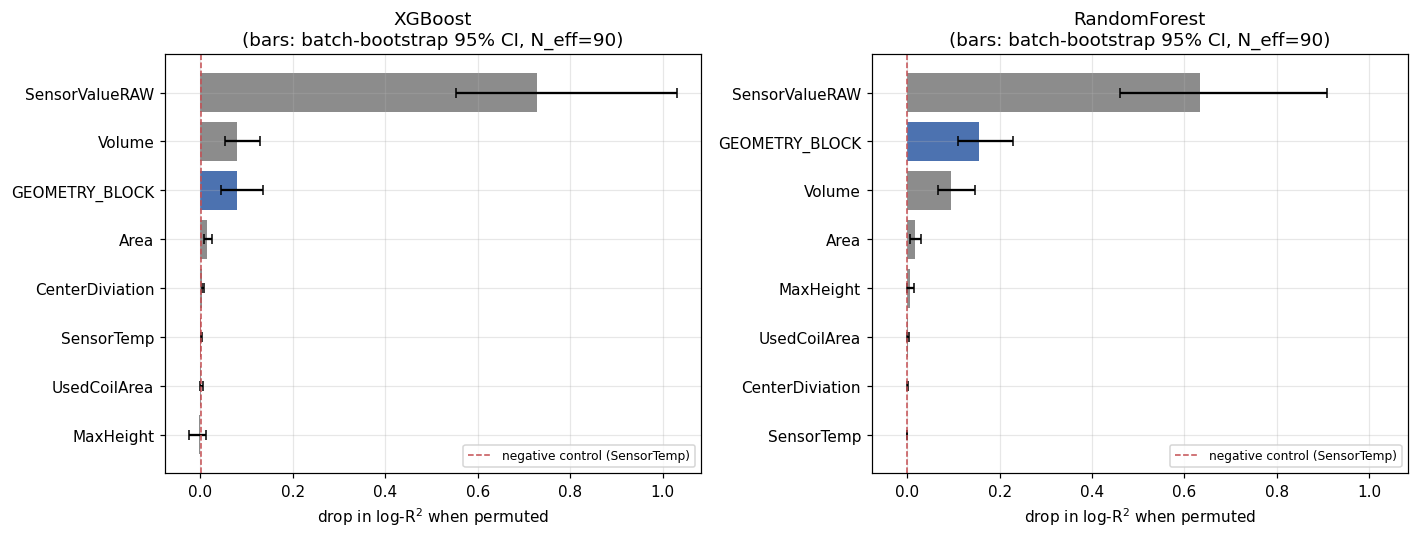

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, name in zip(axes, MODELS):
    sub = agg[agg.model == name].sort_values("importance")
    colors = ["#c44e52" if b == NEGATIVE_CONTROL else
              "#4c72b0" if b == "GEOMETRY_BLOCK" else "#8c8c8c"
              for b in sub.block]
    ax.barh(sub.block, sub.importance,
            xerr=[sub.importance - sub.ci_lo, sub.ci_hi - sub.importance],
            color=colors, capsize=3)
    ax.axvline(control[name], ls="--", c="#c44e52", lw=1,
               label=f"negative control ({NEGATIVE_CONTROL})")
    ax.set_title(f"{name}\n(bars: batch-bootstrap 95% CI, N_eff={N_EFF})")
    ax.set_xlabel("drop in log-R$^2$ when permuted")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/permutation_importance.png", bbox_inches="tight")
plt.show()

## Block 6 - The conditional question

Permutation asks what a *fitted* model leans on. Ablation asks what is *recoverable* - each subset
is retrained from scratch. The two disagree exactly where collinearity lets a model substitute one
column for another, which is the interesting case here.

The headline comparison is `SensorValueRAW` alone versus all seven: it measures what the geometry
channels contribute **on top of** the dominant induction reading.

In [13]:
SUBSETS = {
    "all_7":             FEATURES,
    "RAW_only":          ["SensorValueRAW"],
    "no_RAW":            [c for c in FEATURES if c != "SensorValueRAW"],
    "RAW_plus_geometry": ["SensorValueRAW"] + GEOMETRY_BLOCK,
}
for c in FEATURES:
    SUBSETS[f"drop_{c}"] = [x for x in FEATURES if x != c]

abl_rows, preds_by_subset = [], {}
for name, b in bands.items():
    best_params = b["band"].iloc[0]["params"]
    for label, cols in SUBSETS.items():
        pred, _ = oof_predictions(b["make"](**best_params), dev[cols], y_dev, g_dev)
        preds_by_subset[(name, label)] = pred
        abl_rows.append({
            "model": name, "subset": label, "n_features": len(cols),
            "log_r2": log_r2(y_dev, pred), "raw_r2": r2_score(y_dev, pred),
            "rmse": root_mean_squared_error(y_dev, pred),
            "mae": mean_absolute_error(y_dev, pred),
        })

ablation = pd.DataFrame(abl_rows)
# paired batch-bootstrap of every subset against the full 7-feature model
for i, r in ablation.iterrows():
    if r["subset"] == "all_7":
        ablation.loc[i, ["delta_vs_all7", "d_lo", "d_hi", "d_p"]] = [0.0, 0.0, 0.0, 1.0]
        continue
    res = cluster_bootstrap_paired(y_dev, preds_by_subset[(r["model"], r["subset"])],
                                   preds_by_subset[(r["model"], "all_7")], g_dev)
    ablation.loc[i, ["delta_vs_all7", "d_lo", "d_hi", "d_p"]] = [
        res["delta"], res["lo"], res["hi"], res["p_two_sided"]]

for name in MODELS:
    sub = ablation[ablation.model == name].sort_values("log_r2", ascending=False)
    print(f"\n=== {name}: retrained ablations (delta vs the full 7-feature model) ===")
    print(sub[["subset", "n_features", "log_r2", "delta_vs_all7", "d_lo", "d_hi",
               "d_p", "rmse"]].round(4).to_string(index=False))
ablation.to_csv(f"{OUTPUT_DIR}/ablation.csv", index=False)


=== XGBoost: retrained ablations (delta vs the full 7-feature model) ===
              subset  n_features  log_r2  delta_vs_all7    d_lo    d_hi   d_p    rmse
      drop_MaxHeight           6  0.9451         0.0050 -0.0119  0.0278 0.680 30.6545
               all_7           7  0.9401         0.0000  0.0000  0.0000 1.000 29.4626
           drop_Area           6  0.9378        -0.0022 -0.0103  0.0046 0.495 30.5533
     drop_SensorTemp           6  0.9358        -0.0043 -0.0084 -0.0010 0.015 29.6749
drop_CenterDiviation           6  0.9337        -0.0064 -0.0123 -0.0029 0.000 29.4434
         drop_Volume           6  0.9337        -0.0064 -0.0213  0.0027 0.200 27.0287
   drop_UsedCoilArea           6  0.9337        -0.0064 -0.0134 -0.0015 0.015 29.0819
   RAW_plus_geometry           5  0.9302        -0.0099 -0.0179 -0.0052 0.000 30.6645
            RAW_only           1  0.9200        -0.0201 -0.0517  0.0122 0.190 18.9189
              no_RAW           6  0.2862        -0.6538 -1.0377 -0

## Block 7 - Direction and shape (SHAP)

Permutation and ablation give magnitude. SHAP gives sign and shape: *how* geometry corrects the raw
induction reading. Computed on one representative config per model, fitted on development batches.

Skips cleanly if `shap` is not installed.

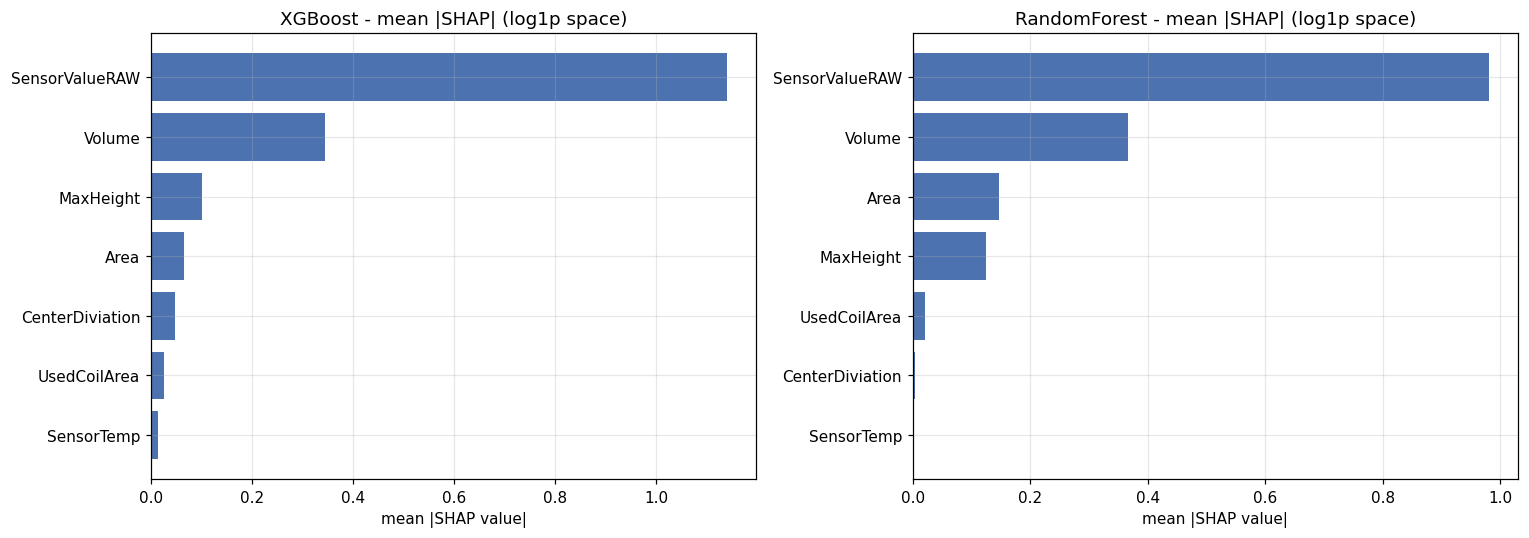

model            RandomForest  XGBoost
feature                               
Area                   0.1471   0.0664
CenterDiviation        0.0032   0.0480
MaxHeight              0.1246   0.1017
SensorTemp             0.0024   0.0144
SensorValueRAW         0.9807   1.1416
UsedCoilArea           0.0207   0.0268
Volume                 0.3659   0.3444


In [14]:
try:
    import shap
    have_shap = True
except ImportError:
    have_shap = False
    print("shap not installed - skipping. Install with: pip install shap "
          "(it is in requirements.txt)")

if have_shap:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    shap_summary = []
    for ax, (name, b) in zip(axes, bands.items()):
        pipe = build_pipeline(b["make"](**b["band"].iloc[0]["params"]))
        pipe.fit(X_dev, y_dev)
        fitted = pipe.named_steps["model"].regressor_    # SHAP is in log1p space
        sv = shap.TreeExplainer(fitted).shap_values(X_dev)

        mean_abs = np.abs(sv).mean(axis=0)
        for f, m in zip(FEATURES, mean_abs):
            shap_summary.append({"model": name, "feature": f, "mean_abs_shap": m})

        order = np.argsort(mean_abs)
        ax.barh([FEATURES[i] for i in order], mean_abs[order], color="#4c72b0")
        ax.set_title(f"{name} - mean |SHAP| (log1p space)")
        ax.set_xlabel("mean |SHAP value|")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/shap_importance.png", bbox_inches="tight")
    plt.show()

    shap_df = pd.DataFrame(shap_summary)
    shap_df.to_csv(f"{OUTPUT_DIR}/shap_importance.csv", index=False)
    print(shap_df.pivot(index="feature", columns="model",
                        values="mean_abs_shap").round(4).to_string())

## Block 8 - Engineered feature candidates

Two arms:

- **physics** - named, mechanism-motivated quantities. Each asks a specific question about how the
  raw induction reading relates to how much of the fragment the coil actually sees. Includes the
  three features `system_technologies.ipynb` Cell 1 computes but Cell 7 discards.
- **broad** - a deliberately *small* automated arm. At N_eff = 90 a large arm cannot survive
  multiplicity correction, so breadth is capped on purpose rather than by accident.

Each candidate is scored by the **paired, batch-bootstrapped log-R^2 gain** it adds on top of the
full seven-feature baseline, with Benjamini-Hochberg FDR across candidates. Selection uses
development batches only.

In [15]:
def physics_candidates(df):
    out = {
        "RawPerCoilArea":   df.SensorValueRAW / (df.UsedCoilArea + EPS),
        "RawPerVolume":     df.SensorValueRAW / (df.Volume + EPS),
        "RawPerArea":       df.SensorValueRAW / (df.Area + EPS),
        "CoilCoverage":     df.UsedCoilArea / (df.Area + EPS),
        "RawTimesCoverage": df.SensorValueRAW * (df.UsedCoilArea / (df.Area + EPS)),
        # the three Cell 1 computes but never uses
        "AspectRatio":      df.MaxHeight / (df.Area ** 0.5 + EPS),
        "Density":          df.Volume / (df.Area + EPS),
        "NormDeviation":    np.sqrt(np.clip(df.CenterDiviation, 0, None) / (df.Area ** 0.5 + EPS)),
    }
    return pd.DataFrame(out, index=df.index)


def broad_candidates(df):
    out = {}
    for a in [c for c in FEATURES if c != "SensorValueRAW"]:
        out[f"ratio_{a}_to_Area"] = df[a] / (df.Area + EPS)
        out[f"log_{a}"] = np.log1p(np.clip(df[a], 0, None))
    for a in ("Volume", "Area", "UsedCoilArea", "MaxHeight"):
        out[f"prod_RAW_x_{a}"] = df.SensorValueRAW * df[a]
    out = {k: v for k, v in out.items() if np.isfinite(v).all() and v.std() > 0}
    return pd.DataFrame(out, index=df.index)


cand_dev = pd.concat([physics_candidates(dev), broad_candidates(dev)], axis=1)
cand_dev = cand_dev.loc[:, ~cand_dev.columns.duplicated()]
ARMS = {**{c: "physics" for c in physics_candidates(dev).columns},
        **{c: "broad" for c in broad_candidates(dev).columns}}
print(f"{len(cand_dev.columns)} candidates "
      f"({sum(v == 'physics' for v in ARMS.values())} physics, "
      f"{sum(v == 'broad' for v in ARMS.values())} broad)")


def benjamini_hochberg(p, q=FDR_Q):
    p = np.asarray(p, dtype=float)
    order = np.argsort(p)
    passed = p[order] <= q * np.arange(1, len(p) + 1) / len(p)
    keep = np.zeros(len(p), dtype=bool)
    if passed.any():
        keep[order[:np.flatnonzero(passed).max() + 1]] = True
    return keep


screen_model = "XGBoost"                     # screen with the cheaper model
screen_make = bands[screen_model]["make"]
screen_params = bands[screen_model]["band"].iloc[0]["params"]

t0 = time.perf_counter()
base_pred, _ = oof_predictions(screen_make(**screen_params), X_dev, y_dev, g_dev)
rows = []
for j, col in enumerate(cand_dev.columns, start=1):
    X_aug = X_dev.copy()
    X_aug[col] = cand_dev[col].to_numpy()
    pred, _ = oof_predictions(screen_make(**screen_params), X_aug, y_dev, g_dev)
    r = cluster_bootstrap_paired(y_dev, pred, base_pred, g_dev)
    rows.append({"candidate": col, "arm": ARMS[col], "gain_log_r2": r["delta"],
                 "lo": r["lo"], "hi": r["hi"], "p": r["p_two_sided"]})
    if j % PROGRESS_EVERY == 0 or j == len(cand_dev.columns):
        progress("screening", j, len(cand_dev.columns), t0)

screen = pd.DataFrame(rows).sort_values("gain_log_r2", ascending=False).reset_index(drop=True)
screen["passes_fdr"] = benjamini_hochberg(screen["p"].to_numpy())
screen["selected"] = screen.passes_fdr & (screen.gain_log_r2 > 0) & (screen.lo > 0)
screen.to_csv(f"{OUTPUT_DIR}/candidate_screen.csv", index=False)

print(f"baseline dev log-R^2 = {log_r2(y_dev, base_pred):.4f}  "
      f"({time.perf_counter() - t0:.0f}s)\n")
print(screen.round(4).to_string(index=False))
selected = screen.loc[screen.selected, "candidate"].tolist()
print(f"\nselected: {selected if selected else 'NONE'}")

24 candidates (8 physics, 16 broad)
  screening        [████··················]   5/24   0.1m elapsed, ~ 0.5m left
  screening        [█████████·············]  10/24   0.2m elapsed, ~ 0.3m left
  screening        [█████████████·········]  15/24   0.3m elapsed, ~ 0.2m left
  screening        [██████████████████····]  20/24   0.4m elapsed, ~ 0.1m left
  screening        [██████████████████████]  24/24   0.5m elapsed, ~ 0.0m left
baseline dev log-R^2 = 0.9401  (32s)

                    candidate     arm  gain_log_r2      lo      hi     p  passes_fdr  selected
         prod_RAW_x_MaxHeight   broad       0.0026 -0.0020  0.0076 0.285       False     False
             RawTimesCoverage physics       0.0020 -0.0008  0.0052 0.170       False     False
            prod_RAW_x_Volume   broad       0.0004 -0.0042  0.0042 0.880       False     False
      prod_RAW_x_UsedCoilArea   broad       0.0003 -0.0021  0.0025 0.770       False     False
           ratio_Area_to_Area   broad      -0.0008 -0.00

## Block 9 - Confirmation on the sealed batches

The sealed batches are used here and nowhere else. Both models are fitted on development batches
with the baseline feature set and with the selected additions, then scored once on the seal.

With 20 sealed batches this test has limited power - it can only detect a fairly large effect. The
confidence interval is reported rather than a bare pass/fail so that "not detected" cannot be
misread as "not there".

In [16]:
def fit_and_score(make, params, cols, cand_cols=()):
    X_tr, X_te = dev[list(cols)].copy(), seal[list(cols)].copy()
    if cand_cols:
        ctr, cte = physics_candidates(dev), physics_candidates(seal)
        btr, bte = broad_candidates(dev), broad_candidates(seal)
        for c in cand_cols:
            X_tr[c] = (ctr[c] if c in ctr else btr[c]).to_numpy()
            X_te[c] = (cte[c] if c in cte else bte[c]).to_numpy()
    pipe = build_pipeline(make(**params))
    pipe.fit(X_tr, y_dev)
    return pipe.predict(X_te)


conf_rows, conf_preds = [], {}
for name, b in bands.items():
    params = b["band"].iloc[0]["params"]
    variants = {"baseline_7": ()}
    if selected:
        variants["baseline_7 + selected"] = tuple(selected)
    for label, extra in variants.items():
        pred = fit_and_score(b["make"], params, FEATURES, extra)
        conf_preds[(name, label)] = pred
        conf_rows.append({
            "model": name, "variant": label, "n_features": len(FEATURES) + len(extra),
            "log_r2": log_r2(y_seal, pred), "raw_r2": r2_score(y_seal, pred),
            "rmse": root_mean_squared_error(y_seal, pred),
            "mae": mean_absolute_error(y_seal, pred),
        })

confirm = pd.DataFrame(conf_rows)
print("=== sealed-batch confirmation (20 batches, non-extreme range) ===")
print(confirm.round(4).to_string(index=False))

if selected:
    print("\n=== did the selected features survive? (paired batch bootstrap on the seal) ===")
    for name in MODELS:
        r = cluster_bootstrap_paired(y_seal, conf_preds[(name, "baseline_7 + selected")],
                                     conf_preds[(name, "baseline_7")], g_seal)
        verdict = "CONFIRMED" if r["lo"] > 0 else "NOT CONFIRMED"
        print(f"  {name:14} delta log-R^2 = {r['delta']:+.4f}  "
              f"95% CI [{r['lo']:+.4f}, {r['hi']:+.4f}]  p={r['p_two_sided']:.3f}  {verdict}")
else:
    print("\nNo candidate passed the development screen, so there is nothing to confirm.")

print("\n=== XGBoost vs RandomForest on the seal (the question that started this) ===")
r = cluster_bootstrap_paired(y_seal, conf_preds[("XGBoost", "baseline_7")],
                             conf_preds[("RandomForest", "baseline_7")], g_seal)
print(f"  delta log-R^2 (XGB - RF) = {r['delta']:+.4f}  "
      f"95% CI [{r['lo']:+.4f}, {r['hi']:+.4f}]  p={r['p_two_sided']:.3f}")
print(f"  => {'distinguishable' if r['lo'] > 0 or r['hi'] < 0 else 'NOT distinguishable at N_eff=20'}")
confirm.to_csv(f"{OUTPUT_DIR}/confirmation.csv", index=False)

=== sealed-batch confirmation (20 batches, non-extreme range) ===
       model    variant  n_features  log_r2  raw_r2   rmse    mae
     XGBoost baseline_7           7  0.9466  0.9454 7.5891 4.7298
RandomForest baseline_7           7  0.9486  0.9216 9.0922 5.7477

No candidate passed the development screen, so there is nothing to confirm.

=== XGBoost vs RandomForest on the seal (the question that started this) ===
  delta log-R^2 (XGB - RF) = -0.0020  95% CI [-0.0119, +0.0066]  p=0.685
  => NOT distinguishable at N_eff=20


## Block 10 - Verdict

In [17]:
lines = []
lines.append(f"Effective sample size: {N_EFF} batches ({len(data)} rows).")
lines.append("")
lines.append("Feature importance (drop in log-R^2 when permuted, batch-bootstrap 95% CI):")
for name in MODELS:
    sub = agg[agg.model == name].sort_values("importance", ascending=False)
    real = sub[sub.above_control]
    null = sub[~sub.above_control]
    lines.append(f"  {name}:")
    for _, r in real.iterrows():
        lines.append(f"    REAL  {r.block:16} {r.importance:+.4f} "
                     f"[{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]  +/-{r.across_config_sd:.4f} across configs")
    for _, r in null.iterrows():
        lines.append(f"    null  {r.block:16} {r.importance:+.4f} "
                     f"[{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]")

lines.append("")
lines.append("Conditional contribution (dev, retrained):")
for name in MODELS:
    s = ablation[ablation.model == name].set_index("subset")
    lines.append(f"  {name}: RAW alone {s.loc['RAW_only','log_r2']:.4f} -> "
                 f"all 7 {s.loc['all_7','log_r2']:.4f} "
                 f"(geometry adds {s.loc['all_7','log_r2'] - s.loc['RAW_only','log_r2']:+.4f}); "
                 f"without RAW {s.loc['no_RAW','log_r2']:.4f}")

lines.append("")
lines.append(f"Engineered features: {len(cand_dev.columns)} screened, "
             f"{len(selected)} passed FDR q={FDR_Q} on dev -> {selected if selected else 'none'}")
if selected:
    for name in MODELS:
        r = cluster_bootstrap_paired(y_seal, conf_preds[(name, 'baseline_7 + selected')],
                                     conf_preds[(name, 'baseline_7')], g_seal)
        lines.append(f"  sealed confirmation {name}: {r['delta']:+.4f} "
                     f"[{r['lo']:+.4f}, {r['hi']:+.4f}] "
                     f"{'CONFIRMED' if r['lo'] > 0 else 'not confirmed'}")

lines.append("")
lines.append("Caveats carried by this analysis:")
lines.append(f"  - Confirmation covers the non-extreme range only; the 2 batches above 200")
lines.append(f"    are needed in training and cannot also be held out.")
lines.append(f"  - Seal has {g_seal.nunique()} batches: low power, wide intervals by construction.")
lines.append(f"  - Bootstrap p-values are descriptive levels, not exact tests.")

report = "\n".join(lines)
print(report)
with open(f"{OUTPUT_DIR}/verdict.txt", "w") as fh:
    fh.write(report + "\n")
print(f"\nartifacts written to {OUTPUT_DIR}/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

Effective sample size: 90 batches (4161 rows).

Feature importance (drop in log-R^2 when permuted, batch-bootstrap 95% CI):
  XGBoost:
    REAL  SensorValueRAW   +0.7288 [+0.5525, +1.0308]  +/-0.0101 across configs
    REAL  Volume           +0.0802 [+0.0524, +0.1281]  +/-0.0116 across configs
    REAL  GEOMETRY_BLOCK   +0.0794 [+0.0441, +0.1352]  +/-0.0048 across configs
    REAL  Area             +0.0152 [+0.0072, +0.0251]  +/-0.0022 across configs
    REAL  CenterDiviation  +0.0040 [+0.0026, +0.0069]  +/-0.0002 across configs
    null  SensorTemp       +0.0023 [+0.0014, +0.0042]
    null  UsedCoilArea     +0.0022 [-0.0007, +0.0055]
    null  MaxHeight        -0.0027 [-0.0239, +0.0122]
  RandomForest:
    REAL  SensorValueRAW   +0.6331 [+0.4600, +0.9086]  +/-0.0018 across configs
    REAL  GEOMETRY_BLOCK   +0.1564 [+0.1107, +0.2284]  +/-0.0016 across configs
    REAL  Volume           +0.0943 [+0.0661, +0.1464]  +/-0.0028 across configs
    REAL  Area             +0.0174 [+0.0052, +0